In [1]:
import json
from pathlib import Path

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

INFO: P [MainThread] 2025-10-30 17:46:33,259 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
performance_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency/transfer_performance_MAP_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

performance_scores.pop("DSB2018", None)

{'BC_IN_model2': 0.4842800498008728,
 'HN_IN_model2': 0.5206860899925232,
 'Hst_IN_model3': 0.31693270802497864,
 '895_IN_model2': 0.43998968601226807,
 '1410_IN_model1': 0.49643415212631226}

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency/gauss/ARE/transfer_Gauss_a0-005_Forg_ARE_scores.json
Processing: gauss_Consistency_a0-005
Number of targets: 4
  Target 1: BBBC039
  Target 2: Hoechst
  Target 3: S_BIAD895
  Target 4: S_BIAD634


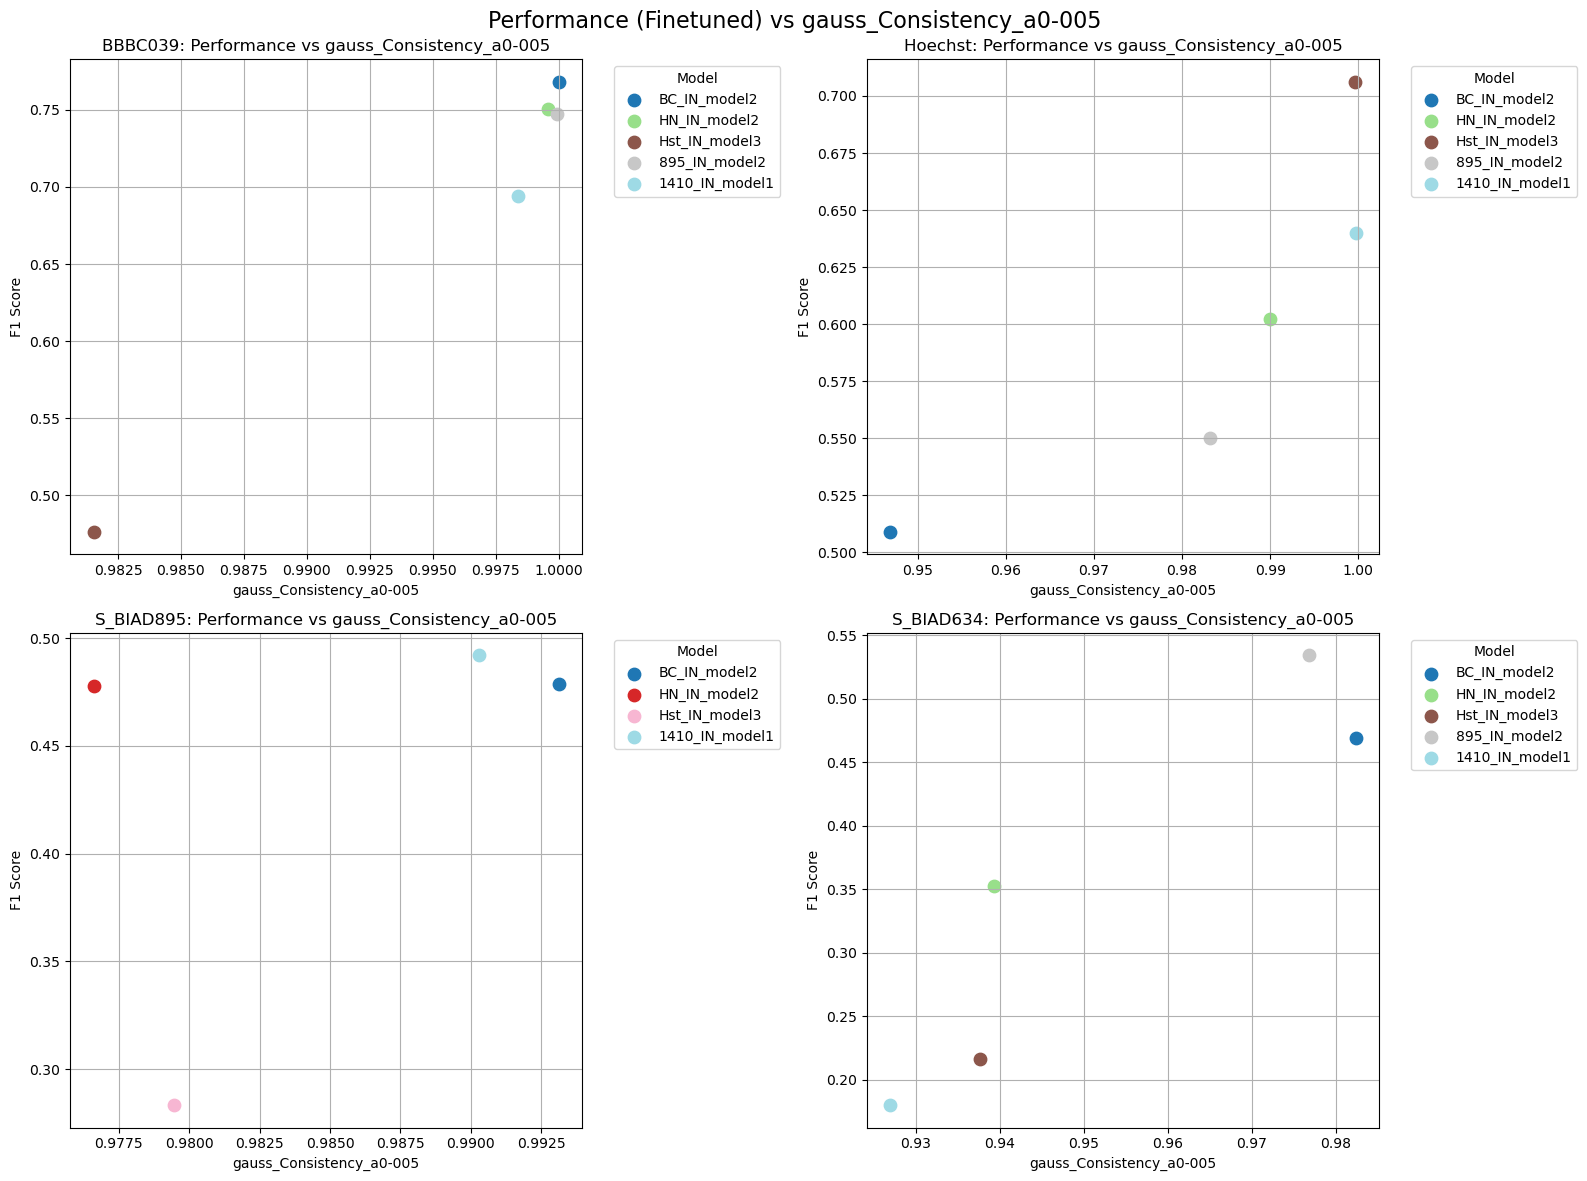

                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.80     0.08    0.9        0.09  0.99     0.00
     Hoechst    0.80     0.09    0.9        0.09  0.85     0.07
     S_BIAD895  0.33     0.75    0.6        0.42  0.47     0.53
     S_BIAD634  0.80     0.09    0.9        0.08  0.93     0.02
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency/gauss/ARE/transfer_Gauss_a005-01_Forg_ARE_scores.json
Processing: gauss_Consistency_a005-01
Number of targets: 4
  Target 1: BBBC039
  Target 2: Hoechst
  Target 3: S_BIAD895
  Target 4: S_BIAD634


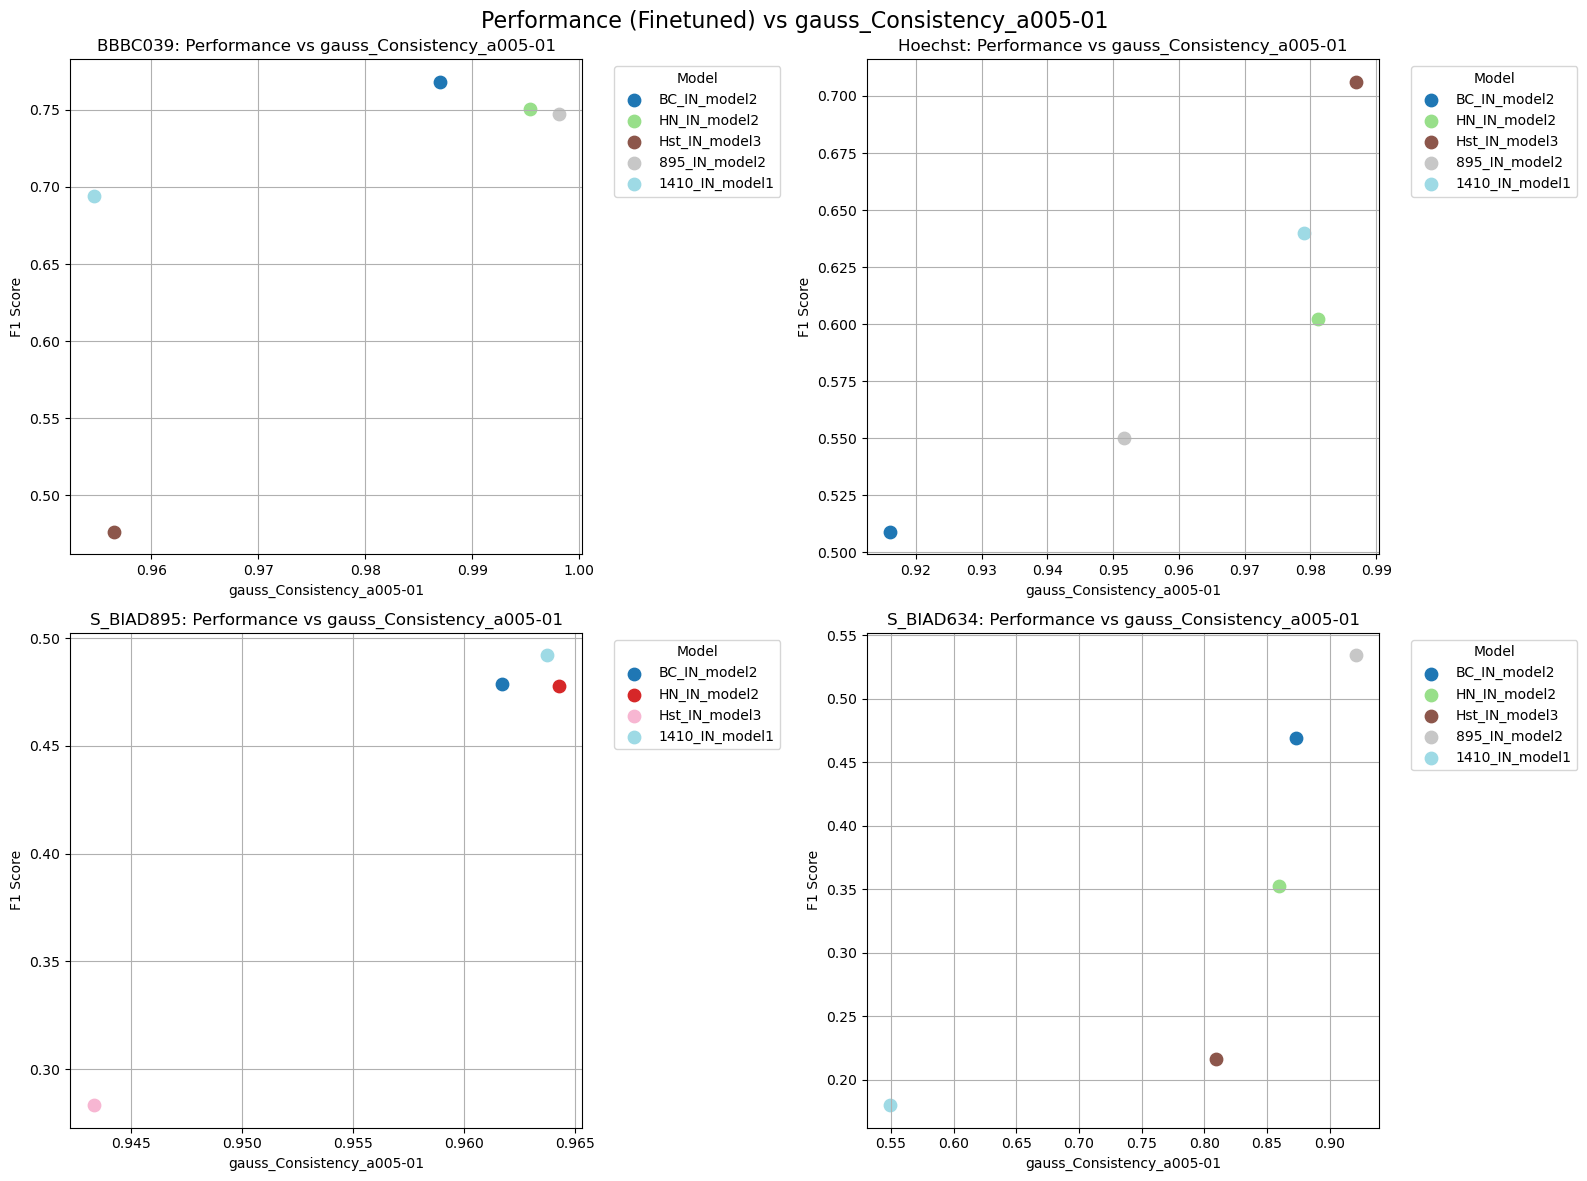

                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.20     0.83    0.5        0.47  0.72     0.17
     Hoechst    0.80     0.07    0.9        0.08  0.89     0.04
     S_BIAD895  0.33     0.75    0.4        0.75  0.99     0.01
     S_BIAD634  1.00     0.02    1.0        0.02  0.80     0.10
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency/gauss/ARE/transfer_Gauss_a01-02_Forg_ARE_scores.json
Processing: gauss_Consistency_a01-02
Number of targets: 4
  Target 1: BBBC039
  Target 2: Hoechst
  Target 3: S_BIAD895
  Target 4: S_BIAD634


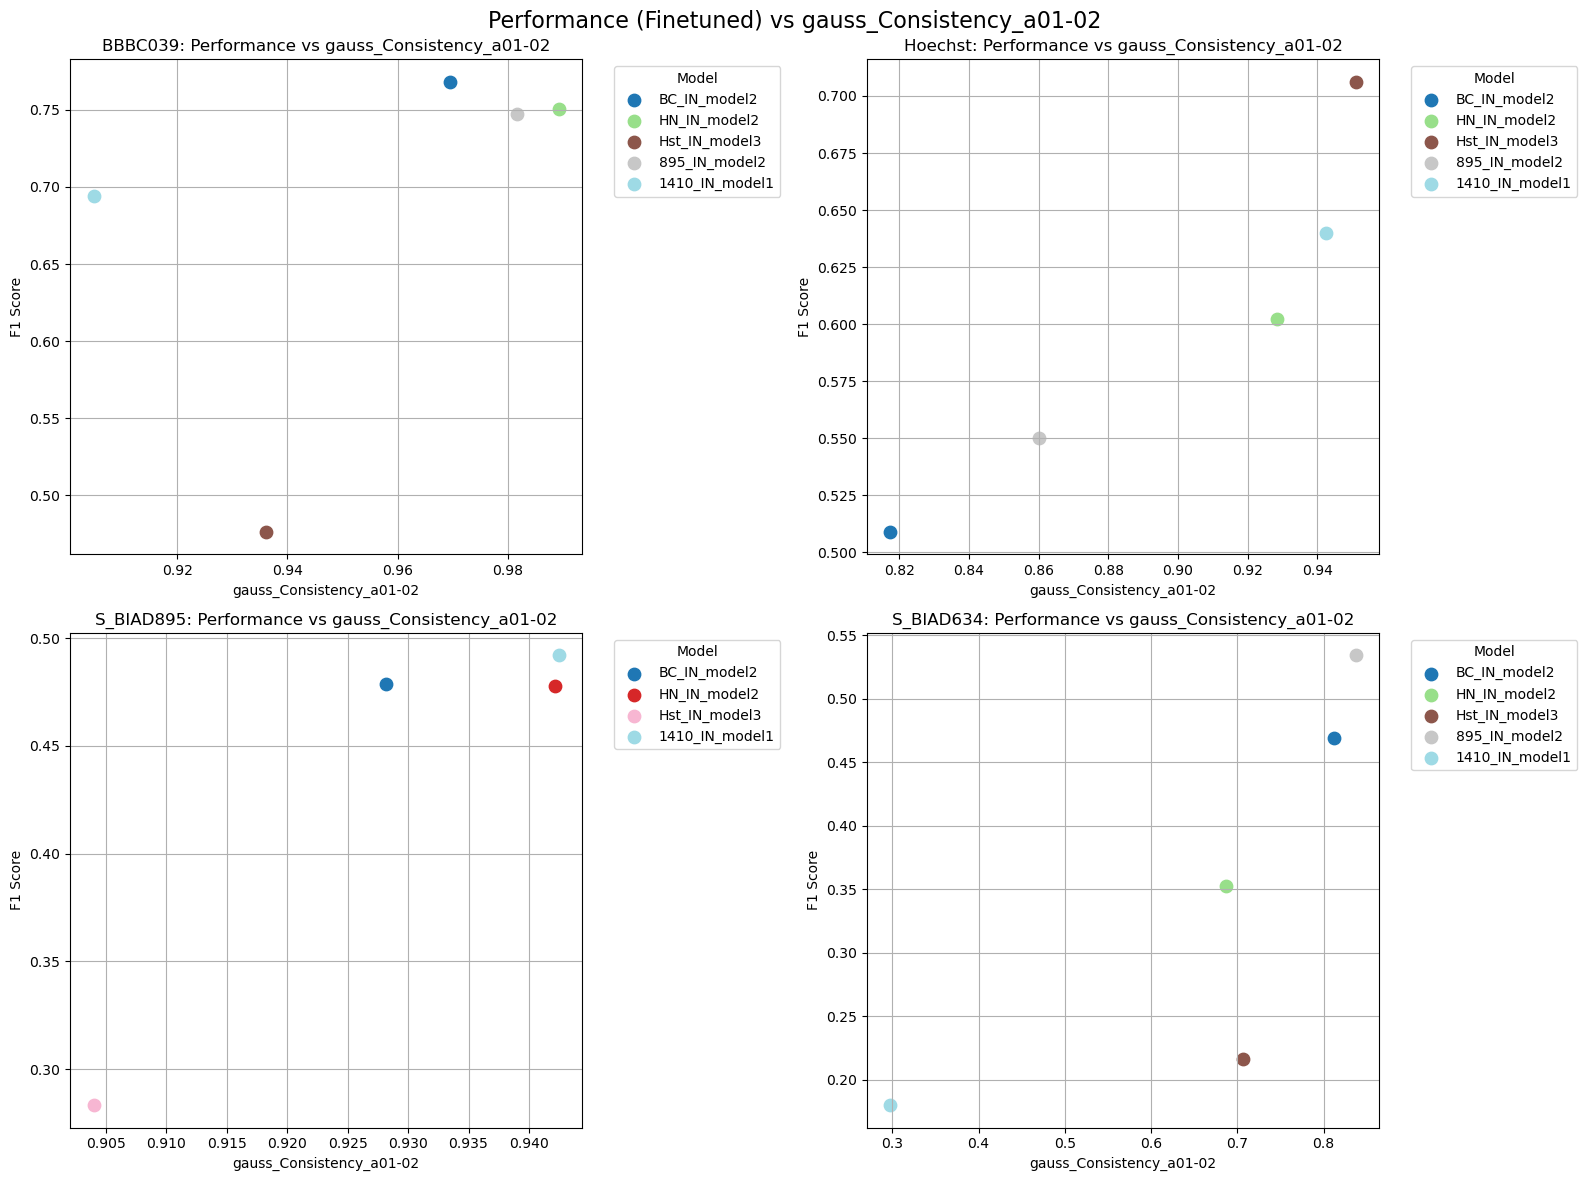

                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.40     0.48    0.6        0.33  0.50     0.39
     Hoechst    1.00     0.02    1.0        0.02  0.93     0.02
     S_BIAD895  0.67     0.33    0.8        0.33  0.94     0.06
     S_BIAD634  0.80     0.13    0.9        0.08  0.79     0.11


In [5]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency/gauss/ARE"
selected_augmentations = ["a0-005", "a005-01", "a01-02"]

for aug in selected_augmentations:
    file_name = f"transfer_Gauss_{aug}_Forg_ARE_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    consistency_scores.pop("DSB2018", None)
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
        transfer_scores=consistency_scores,
        transfer_metric=f"gauss_Consistency_{aug}",
        finetuned=True,
        invert_transfer_metric=True,
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        invert_transfer_metric=True,
        )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        